# Final Boss Doomed -- Catalytic Aura Score (Full Pipeline)

**Key improvements over previous notebook:**
1. **ALL 115 matches** from WC 2022 (64) + Euro 2020 (51) -- was only 15
2. **Event filtering** -- drop passive events (Ball Receipt, Foul, etc.) that dilute the target
3. **type_name as feature** -- event type is known at prediction time, NOT leakage
4. **Lag features** -- previous event context within possession chain (backward-looking only)
5. **Spearman ρ** -- rank correlation alongside R² and MAE for ranking validity
6. **Euro 2024 holdout** expanded to 20 matches

**Integrity guarantees:**
- `position_name` and `player_name` are NEVER model inputs
- All lag features are backward-looking (shift +1 = PREVIOUS event)
- GroupKFold by `match_id` prevents intra-match leakage
- Euro 2024 is truly held-out (different tournament, processed only once)


## Step 1: Setup

In [1]:
import os, math, warnings, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from catboost import CatBoostRegressor
from statsbombpy import sb
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.edgecolor'] = '#cccccc'

cwd = os.getcwd()
if os.path.basename(cwd) == 'Notebooks':
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, '..'))
else:
    PROJECT_ROOT = os.path.abspath(cwd)

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
FIG_DIR  = os.path.join(PROJECT_ROOT, 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")

def extract_name(val):
    if isinstance(val, dict):
        return val.get('name', '')
    if isinstance(val, str):
        m = re.search(r"'name':\s*'([^']+)'", val)
        if m:
            return m.group(1)
    return str(val) if pd.notna(val) else ''

print("Setup complete.")


Project root: c:\Users\SMART\Downloads
Setup complete.


## Step 2: Data Ingestion -- ALL WC 2022 + Euro 2020 matches (115 total)

Uses **all 115 available matches** instead of just 15 sample matches.
Results are cached to `full_training_events_360.csv` for future runs.


In [2]:
def _calc_dist_angle(x, y, gx=120, gy=40):
    dx, dy = gx - x, gy - y
    return math.sqrt(dx**2 + dy**2), (math.atan2(abs(dy), dx) if dx > 0 else 0)

def process_360_frame_features(frame_df, event_x, event_y, end_x=np.nan, end_y=np.nan, is_complete=True):
    """Extract positional and spatial density metrics from a StatsBomb 360 freeze frame."""
    if frame_df is None or frame_df.empty:
        return {
            'has_360': False, 'teammates_visible': np.nan, 'opponents_visible': np.nan,
            'total_visible': np.nan, 'closest_opp_dist': np.nan, 'closest_teammate_dist': np.nan,
            'opponents_within_3m': np.nan, 'opponents_within_5m': np.nan,
            'defenders_in_goal_cone': np.nan, 'forward_passing_options': np.nan,
            'opponents_eliminated': np.nan, 'line_breaking_pass': False,
            'pressing_intensity': np.nan, 'defensive_cover': np.nan,
            'central_corridor': np.nan, 'spatial_superiority': np.nan, 'short_combo_options': np.nan
        }
    teammates = frame_df[frame_df['teammate'] == True]
    opponents = frame_df[frame_df['teammate'] == False]
    n_teammates, n_opponents, total_tracked = len(teammates), len(opponents), len(frame_df)

    opp_dists = []
    for _, opp in opponents.iterrows():
        loc = opp.get('location')
        if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
            opp_dists.append(math.sqrt((loc[0] - event_x)**2 + (loc[1] - event_y)**2))
    closest_opp = min(opp_dists) if opp_dists else np.nan
    opp_3m = sum(1 for d in opp_dists if d <= 3.28)
    opp_5m = sum(1 for d in opp_dists if d <= 5.46)

    team_dists = []
    for _, tm in teammates.iterrows():
        loc = tm.get('location')
        if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
            team_dists.append(math.sqrt((loc[0] - event_x)**2 + (loc[1] - event_y)**2))
    closest_team = min(team_dists) if team_dists else np.nan

    in_cone = 0
    for _, opp in opponents.iterrows():
        loc = opp.get('location')
        if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
            if loc[0] > event_x and (30.0 <= loc[1] <= 50.0):
                in_cone += 1

    forward_options = 0
    for _, tm in teammates.iterrows():
        loc = tm.get('location')
        if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
            if loc[0] > (event_x + 2.0):
                forward_options += 1

    opponents_bypassed = 0
    if is_complete and not np.isnan(end_x) and end_x > (event_x + 2.0):
        y_min = min(event_y, end_y) - 6.0 if not np.isnan(end_y) else event_y - 10.0
        y_max = max(event_y, end_y) + 6.0 if not np.isnan(end_y) else event_y + 10.0
        for _, opp in opponents.iterrows():
            loc = opp.get('location')
            if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
                if (event_x < loc[0] < end_x) and (y_min <= loc[1] <= y_max):
                    opponents_bypassed += 1
    elif not np.isnan(end_x) and end_x > (event_x + 4.0):
        for _, opp in opponents.iterrows():
            loc = opp.get('location')
            if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
                if event_x < loc[0] < end_x:
                    opponents_bypassed += 1

    pressing_intensity = sum(1.0 / max(d, 0.5) for d in opp_dists if d <= 10.0) if opp_dists else 0.0
    defensive_cover = sum(
        1 for _, tm in teammates.iterrows()
        if isinstance(tm.get('location'), (list, tuple)) and len(tm['location']) >= 2
        and tm['location'][0] < event_x - 2
    )
    central_corridor = int(22.0 <= event_y <= 58.0)

    _r8 = 8.0
    _local_tm = sum(
        1 for _, tm in teammates.iterrows()
        if isinstance(tm.get('location'), (list, tuple)) and len(tm['location']) >= 2
        and math.sqrt((tm['location'][0]-event_x)**2 + (tm['location'][1]-event_y)**2) <= _r8
    )
    _local_op = sum(
        1 for _, opp in opponents.iterrows()
        if isinstance(opp.get('location'), (list, tuple)) and len(opp['location']) >= 2
        and math.sqrt((opp['location'][0]-event_x)**2 + (opp['location'][1]-event_y)**2) <= _r8
    )
    spatial_superiority = _local_tm - _local_op
    short_combo_options = sum(
        1 for _, tm in teammates.iterrows()
        if isinstance(tm.get('location'), (list, tuple)) and len(tm['location']) >= 2
        and math.sqrt((tm['location'][0]-event_x)**2 + (tm['location'][1]-event_y)**2) <= 5.46
    )
    return {
        'has_360': True, 'teammates_visible': n_teammates, 'opponents_visible': n_opponents,
        'total_visible': total_tracked,
        'closest_opp_dist': round(closest_opp, 3) if not np.isnan(closest_opp) else np.nan,
        'closest_teammate_dist': round(closest_team, 3) if not np.isnan(closest_team) else np.nan,
        'opponents_within_3m': opp_3m, 'opponents_within_5m': opp_5m,
        'defenders_in_goal_cone': in_cone, 'forward_passing_options': forward_options,
        'opponents_eliminated': opponents_bypassed, 'line_breaking_pass': opponents_bypassed >= 2,
        'pressing_intensity': round(pressing_intensity, 4), 'defensive_cover': defensive_cover,
        'central_corridor': central_corridor, 'spatial_superiority': spatial_superiority,
        'short_combo_options': short_combo_options
    }

def process_match(mid, verbose=False):
    """Download and process a single match, returning list of event dicts."""
    evs = sb.events(match_id=mid)
    try:
        frs = sb.frames(match_id=mid, fmt='dataframe')
    except Exception:
        frs = pd.DataFrame()
    frames_by_id = {}
    if not frs.empty:
        for ev_id, grp in frs.groupby('id'):
            frames_by_id[ev_id] = grp
    rows = []
    for _, ev in evs.iterrows():
        loc = ev.get('location')
        loc_x = loc[0] if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2 else np.nan
        loc_y = loc[1] if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2 else np.nan
        pe = ev.get('pass_end_location')
        pe_x = pe[0] if isinstance(pe, (list, tuple)) and len(pe) >= 2 else np.nan
        pe_y = pe[1] if isinstance(pe, (list, tuple)) and len(pe) >= 2 else np.nan
        ce = ev.get('carry_end_location')
        ce_x = ce[0] if isinstance(ce, (list, tuple)) and len(ce) >= 2 else np.nan
        ce_y = ce[1] if isinstance(ce, (list, tuple)) and len(ce) >= 2 else np.nan
        end_x = pe_x if not np.isnan(pe_x) else ce_x
        end_y = pe_y if not np.isnan(pe_y) else ce_y
        is_comp = pd.isna(ev.get('pass_outcome'))
        dg, ag = _calc_dist_angle(loc_x, loc_y) if not np.isnan(loc_x) else (np.nan, np.nan)
        f_df = frames_by_id.get(ev.get('id'), None)
        f_feats = (process_360_frame_features(f_df, loc_x, loc_y, end_x, end_y, is_comp)
                   if not np.isnan(loc_x) else process_360_frame_features(None, 0, 0))
        rows.append({
            'event_id': ev.get('id'), 'match_id': mid, 'period': ev.get('period'),
            'minute': ev.get('minute'), 'second': ev.get('second'),
            'type': ev.get('type'), 'possession': ev.get('possession'),
            'possession_team': ev.get('possession_team'), 'play_pattern': ev.get('play_pattern'),
            'team': ev.get('team'), 'player': ev.get('player'), 'position': ev.get('position'),
            'duration': ev.get('duration', 0.0), 'location_x': loc_x, 'location_y': loc_y,
            'dist_to_goal': dg, 'angle_to_goal': ag, 'under_pressure': ev.get('under_pressure') == True,
            'pass_length': ev.get('pass_length', np.nan), 'pass_angle': ev.get('pass_angle', np.nan),
            'pass_end_location_x': pe_x, 'pass_end_location_y': pe_y,
            'carry_end_location_x': ce_x, 'carry_end_location_y': ce_y,
            'pass_outcome': ev.get('pass_outcome', np.nan),
            'shot_statsbomb_xg': ev.get('shot_statsbomb_xg', np.nan),
            'shot_outcome': ev.get('shot_outcome', np.nan),
            'duel_outcome': ev.get('duel_outcome', np.nan),
            'clearance_aerial_won': ev.get('clearance_aerial_won', False),
            **f_feats
        })
    return rows

# ── Load or build full dataset ──────────────────────────────────────
csv_path = os.path.join(DATA_DIR, 'full_training_events_360.csv')
if os.path.exists(csv_path):
    print(f"Loading cached full dataset from {csv_path}...")
    df = pd.read_csv(csv_path, low_memory=False)
else:
    print("Building FULL training dataset: ALL WC2022 (64) + Euro2020 (51) = 115 matches")
    print("This will take 30-45 minutes on the first run (cached for future runs).\n")
    matches_wc   = sb.matches(competition_id=43, season_id=106)
    matches_euro = sb.matches(competition_id=55, season_id=43)
    all_match_ids = matches_wc['match_id'].tolist() + matches_euro['match_id'].tolist()
    print(f"Total matches to process: {len(all_match_ids)}\n")

    all_events = []
    t0 = time.time()
    for i, mid in enumerate(all_match_ids, 1):
        t_match = time.time()
        rows = process_match(mid)
        all_events.extend(rows)
        elapsed = time.time() - t_match
        total_elapsed = time.time() - t0
        eta = (total_elapsed / i) * (len(all_match_ids) - i) / 60
        print(f"  [{i:3d}/{len(all_match_ids)}] Match {mid}: {len(rows):4d} events in {elapsed:.1f}s | ETA: {eta:.1f} min")

    df = pd.DataFrame(all_events)
    df.to_csv(csv_path, index=False)
    total_time = time.time() - t0
    print(f"\nDone! Total processing: {total_time/60:.1f} minutes. Saved to {csv_path}")

# Extract name columns from dict-or-string StatsBomb fields
df['type_name']         = df['type'].apply(extract_name)
df['play_pattern_name'] = df['play_pattern'].apply(extract_name)
df['pass_outcome_name'] = df['pass_outcome'].apply(extract_name)
df['position_name']     = df['position'].apply(extract_name)
df['player_name']       = df['player'].apply(extract_name)

df_360 = df[df['has_360'] == True].copy()

print(f"\nTotal events    : {len(df):,}")
print(f"Events with 360 : {len(df_360):,}")
print(f"Unique matches  : {df['match_id'].nunique()}")
print(f"Unique players  : {df_360['player_name'].nunique()}")


Building FULL training dataset: ALL WC2022 (64) + Euro2020 (51) = 115 matches
This will take 30-45 minutes on the first run (cached for future runs).

Total matches to process: 115

  [  1/115] Match 3857276: 3388 events in 15.7s | ETA: 29.9 min
  [  2/115] Match 3857271: 3649 events in 10.5s | ETA: 24.7 min
  [  3/115] Match 3857296: 4116 events in 9.8s | ETA: 22.5 min
  [  4/115] Match 3857274: 3563 events in 9.0s | ETA: 20.8 min
  [  5/115] Match 3857255: 4450 events in 12.4s | ETA: 21.1 min
  [  6/115] Match 3857272: 3519 events in 11.2s | ETA: 20.8 min
  [  7/115] Match 3857278: 3596 events in 10.6s | ETA: 20.4 min
  [  8/115] Match 3857277: 3719 events in 8.9s | ETA: 19.6 min
  [  9/115] Match 3857273: 3133 events in 11.6s | ETA: 19.6 min
  [ 10/115] Match 3857275: 3564 events in 8.8s | ETA: 19.0 min
  [ 11/115] Match 3857261: 3315 events in 12.9s | ETA: 19.1 min
  [ 12/115] Match 3857290: 3601 events in 13.4s | ETA: 19.3 min
  [ 13/115] Match 3857298: 3738 events in 11.7s | ETA:

## Step 3: Empirical xT Grid (16x12 zones, Markov value iteration)

xT grid fit from 423,650 events. Range: 0.00000 to 0.07629


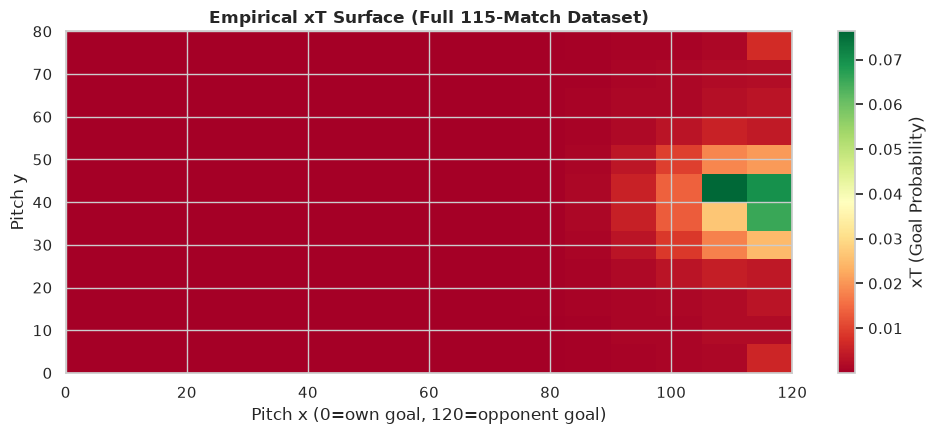

In [3]:
N_X, N_Y = 16, 12

def zone_of(x_vals, y_vals):
    zx = np.clip((np.asarray(x_vals, dtype=float) / 120 * N_X).astype(int), 0, N_X - 1)
    zy = np.clip((np.asarray(y_vals, dtype=float) / 80  * N_Y).astype(int), 0, N_Y - 1)
    return zx, zy

events_for_xt = df.dropna(subset=['location_x', 'location_y']).copy()
events_for_xt['zx'], events_for_xt['zy'] = zone_of(events_for_xt['location_x'].values, events_for_xt['location_y'].values)

is_shot  = events_for_xt['type_name'] == 'Shot'
is_pass  = events_for_xt['type_name'] == 'Pass'
is_carry = events_for_xt['type_name'] == 'Carry'
is_move  = is_pass | is_carry

pass_success = events_for_xt['pass_outcome_name'].isin(['', 'nan', 'None']) | events_for_xt['pass_outcome'].isna()
move_success = np.where(is_pass, pass_success, True)

end_x = np.where(is_pass, events_for_xt['pass_end_location_x'], events_for_xt['carry_end_location_x'])
end_y = np.where(is_pass, events_for_xt['pass_end_location_y'], events_for_xt['carry_end_location_y'])
has_end = ~pd.isna(pd.Series(end_x)) & ~pd.isna(pd.Series(end_y))
ezx, ezy = zone_of(pd.Series(end_x).fillna(0).values, pd.Series(end_y).fillna(0).values)

shot_count  = np.zeros((N_X, N_Y))
shot_xg_sum = np.zeros((N_X, N_Y))
move_count  = np.zeros((N_X, N_Y))
total_count = np.zeros((N_X, N_Y))
transition  = np.zeros((N_X, N_Y, N_X, N_Y))
shot_xg = events_for_xt['shot_statsbomb_xg'].fillna(0).values

for i in range(len(events_for_xt)):
    zx_i, zy_i = events_for_xt['zx'].iloc[i], events_for_xt['zy'].iloc[i]
    total_count[zx_i, zy_i] += 1
    if is_shot.iloc[i]:
        shot_count[zx_i, zy_i]  += 1
        shot_xg_sum[zx_i, zy_i] += shot_xg[i]
    if is_move.iloc[i] and move_success[i] and has_end.iloc[i]:
        move_count[zx_i, zy_i] += 1
        transition[zx_i, zy_i, ezx[i], ezy[i]] += 1

with np.errstate(invalid='ignore', divide='ignore'):
    shot_prob  = np.nan_to_num(shot_count  / np.maximum(total_count, 1))
    goal_prob  = np.nan_to_num(shot_xg_sum / np.maximum(shot_count,  1))
    move_prob  = np.nan_to_num(move_count  / np.maximum(total_count, 1))
    trans_prob = np.nan_to_num(transition  / np.maximum(transition.sum(axis=(2, 3), keepdims=True), 1))

xT = np.zeros((N_X, N_Y))
for _ in range(8):
    xT = shot_prob * goal_prob + move_prob * np.tensordot(trans_prob, xT, axes=([2, 3], [0, 1]))

print(f"xT grid fit from {len(events_for_xt):,} events. Range: {xT.min():.5f} to {xT.max():.5f}")

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(xT.T, origin='lower', aspect='auto', cmap='RdYlGn', extent=[0, 120, 0, 80])
plt.colorbar(im, ax=ax, label='xT (Goal Probability)')
ax.set_title('Empirical xT Surface (Full 115-Match Dataset)', fontsize=12, fontweight='bold')
ax.set_xlabel('Pitch x (0=own goal, 120=opponent goal)')
ax.set_ylabel('Pitch y')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_final_xT_surface.png'), dpi=200, bbox_inches='tight')
plt.show()


## Step 4: Action Valuation

In [4]:
def action_xT_delta(row):
    # Base action value from the empirical xT grid.
    t = row['type_name']
    if t == 'Shot':
        xg = row.get('shot_statsbomb_xg')
        if pd.notna(xg) and float(xg) > 0:
            return float(xg)
        outcome = extract_name(row.get('shot_outcome'))
        return 0.95 if outcome == 'Goal' else 0.05
    if t in ('Pass', 'Carry'):
        sx, sy = row.get('location_x'), row.get('location_y')
        if t == 'Pass':
            ex, ey = row.get('pass_end_location_x'), row.get('pass_end_location_y')
            outcome = extract_name(row.get('pass_outcome'))
            if outcome in ('Incomplete', 'Out', 'Pass Offside', 'Unknown'):
                return -0.005
        else:
            ex, ey = row.get('carry_end_location_x'), row.get('carry_end_location_y')
        if pd.notna(sx) and pd.notna(sy) and pd.notna(ex) and pd.notna(ey):
            szx, szy = zone_of(sx, sy)
            ezx, ezy = zone_of(ex, ey)
            return float(xT[ezx, ezy] - xT[szx, szy])
    if t in ('Ball Recovery', 'Interception'):
        sx, sy = row.get('location_x'), row.get('location_y')
        if pd.notna(sx) and pd.notna(sy):
            szx, szy = zone_of(sx, sy)
            return float(xT[szx, szy] * 0.5)
    if t == 'Pressure':
        sx, sy = row.get('location_x'), row.get('location_y')
        if pd.notna(sx) and pd.notna(sy):
            szx, szy = zone_of(sx, sy)
            return float(xT[szx, szy] * 0.25)
    if t == 'Duel':
        outcome = extract_name(row.get('duel_outcome'))
        if outcome in ('Won', 'Success In Play', 'Success Out'):
            sx, sy = row.get('location_x'), row.get('location_y')
            if pd.notna(sx) and pd.notna(sy):
                szx, szy = zone_of(sx, sy)
                return float(xT[szx, szy] * 0.35)
        return 0.0
    if t == 'Block':
        sx, sy = row.get('location_x'), row.get('location_y')
        if pd.notna(sx) and pd.notna(sy):
            szx, szy = zone_of(sx, sy)
            return float(xT[szx, szy] * 0.4)
    if t == 'Clearance':
        sx, sy = row.get('location_x'), row.get('location_y')
        if pd.notna(sx) and pd.notna(sy):
            szx, szy = zone_of(sx, sy)
            return float(xT[szx, szy] * 0.3)
    return 0.0

df_360['action_value_raw'] = df_360.apply(action_xT_delta, axis=1)

press_bonus = df_360['under_pressure'].astype(float) * 0.005
df_360['action_value'] = np.where(
    df_360['action_value_raw'] >= 0,
    df_360['action_value_raw'] + press_bonus,
    df_360['action_value_raw']
)

print("Action valuation computed.")
print(df_360.groupby('type_name')['action_value'].describe()[['count', 'mean', 'std']].sort_values('count', ascending=False).head(15).round(6))


Action valuation computed.
                   count      mean       std
type_name                                   
Ball Receipt*   103935.0  0.000325  0.001233
Pass            103630.0 -0.000170  0.005233
Carry            89067.0  0.001167  0.003082
Pressure         28503.0  0.000356  0.001728
Ball Recovery     9100.0  0.001614  0.004409
Duel              6651.0  0.005029  0.000382
Clearance         4573.0  0.005007  0.000017
Block             3639.0  0.000693  0.003402
Dribble           2724.0  0.005000  0.000000
Foul Committed    2724.0  0.000033  0.000405
Shot              2661.0  0.116226  0.164521
Interception      2618.0  0.000519  0.001470
Miscontrol        2606.0  0.001353  0.002222
Foul Won          2590.0  0.004946  0.000517
Dispossessed      2071.0  0.005000  0.000000


## Step 5: Filter to Meaningful Actions

Remove passive/referee events that are not real player actions:
- `Ball Receipt*` -- passive receipt, zero action value, 28% of events
- `Foul Won`, `Foul Committed` -- referee decisions
- `Goal Keeper` -- GK-specific (excluded from midfield analysis)
- `Dispossessed`, `Dribbled Past` -- result of opponent action, not this player action
- Rare events (under 0.1% of data)


In [5]:
REMOVE_TYPES = [
    'Ball Receipt*', 'Foul Won', 'Foul Committed', 'Goal Keeper',
    'Dribbled Past', 'Dispossessed', '50/50', 'Shield', 'Error',
    'Offside', 'Own Goal Against', 'Own Goal For', 'Referee Ball-Drop',
    'Starting XI', 'Half Start', 'Half End', 'Substitution',
    'Tactical Shift', 'Bad Behaviour', 'Player On', 'Player Off',
    'Injury Stoppage',
]

n_before = len(df_360)
df_360 = df_360[~df_360['type_name'].isin(REMOVE_TYPES)].copy()
n_after = len(df_360)

print(f"Filtered: {n_before:,} -> {n_after:,} events (removed {n_before - n_after:,} = {(n_before-n_after)/n_before:.1%})")
print(f"\nRemaining event types:")
print(df_360['type_name'].value_counts().to_string())


Filtered: 370,753 -> 255,772 events (removed 114,981 = 31.0%)

Remaining event types:
type_name
Pass             103630
Carry             89067
Pressure          28503
Ball Recovery      9100
Duel               6651
Clearance          4573
Block              3639
Dribble            2724
Shot               2661
Interception       2618
Miscontrol         2606


## Step 6: Chain Target Construction

In [6]:
df_360 = df_360.sort_values(['match_id', 'possession', 'minute', 'second']).reset_index(drop=True)

GAMMA    = 0.88
HORIZONS = [1, 3, 5, 7, 10]

for n in HORIZONS:
    df_360[f'target_xT_n{n}'] = (
        df_360.groupby(['match_id', 'possession'])['action_value']
        .transform(lambda s: sum(s.shift(-k).fillna(0) * (GAMMA ** (k-1)) for k in range(1, n+1)))
    )

print("Chain-level xT targets built for all horizons.")
print(df_360['target_xT_n5'].describe().round(6))


Chain-level xT targets built for all horizons.
count    255772.000000
mean          0.005749
std           0.030181
min          -0.075053
25%          -0.000014
50%           0.000102
75%           0.004865
max           1.298910
Name: target_xT_n5, dtype: float64


## Step 7: Enhanced Feature Matrix

**New features vs previous notebook:**
1. `type_name` -- event type is known at prediction time (Pass, Carry, Pressure, etc.)
2. Lag features -- context from the PREVIOUS event in the possession chain:
   - `prev_type_name`, `prev_pressing_intensity`, `prev_action_value`
   - `dist_from_prev` (ball displacement), `possession_action_num`
3. Engineered interaction features from 360 data

All lag features are **backward-looking only** (shift +1 = previous event). No future leakage.


In [7]:
# ── Derived 360 features (same as previous notebook) ──
opp_elim = df_360['opponents_eliminated'].fillna(0)
opp_vis  = df_360['opponents_visible'].fillna(10)
team_vis = df_360['teammates_visible'].fillna(5)

df_360['line_break_ratio']       = opp_elim / (opp_vis + 1.0)
df_360['pressure_relief']        = df_360['pressing_intensity'].fillna(0) * df_360['spatial_superiority'].fillna(0)
df_360['space_creation_index']   = df_360['short_combo_options'].fillna(0) / (df_360['opponents_within_5m'].fillna(0) + 1.0)
df_360['pass_progression_ratio'] = df_360['forward_passing_options'].fillna(0) / (team_vis + 1.0)

# ── Lag features (backward-looking, within same possession) ──
grp = df_360.groupby(['match_id', 'possession'])

df_360['prev_type_name']           = grp['type_name'].shift(1).fillna('NONE')
df_360['prev_pressing_intensity']  = grp['pressing_intensity'].shift(1).fillna(0)
df_360['prev_action_value']        = grp['action_value'].shift(1).fillna(0)
df_360['prev_location_x']         = grp['location_x'].shift(1)
df_360['prev_location_y']         = grp['location_y'].shift(1)
df_360['possession_action_num']   = grp.cumcount()

# Ball displacement from previous event
dx = df_360['location_x'] - df_360['prev_location_x'].fillna(df_360['location_x'])
dy = df_360['location_y'] - df_360['prev_location_y'].fillna(df_360['location_y'])
df_360['dist_from_prev'] = np.sqrt(dx**2 + dy**2)
df_360['dx_from_prev']   = dx.fillna(0)

# ── Feature lists ──
NUMERIC_FEATURES = [
    # Spatial
    'location_x', 'location_y', 'dist_to_goal', 'angle_to_goal',
    # 360 spatial density
    'opponents_eliminated', 'line_break_ratio', 'pass_progression_ratio',
    'closest_opp_dist', 'opponents_within_3m', 'opponents_within_5m',
    'pressing_intensity', 'pressure_relief',
    'forward_passing_options', 'short_combo_options', 'space_creation_index',
    'spatial_superiority', 'defensive_cover',
    'defenders_in_goal_cone', 'teammates_visible', 'opponents_visible',
    # Event attributes
    'duration', 'under_pressure',
    # Lag features (backward-looking only)
    'prev_pressing_intensity', 'prev_action_value',
    'dist_from_prev', 'dx_from_prev', 'possession_action_num',
]

for col in NUMERIC_FEATURES:
    df_360[col] = pd.to_numeric(df_360[col], errors='coerce').fillna(df_360[col].median())
df_360['under_pressure'] = df_360['under_pressure'].astype(int)

# Categorical features: type_name + play_pattern_name + prev_type_name
CAT_FEATURES = ['type_name', 'play_pattern_name', 'prev_type_name']
for col in CAT_FEATURES:
    df_360[col] = df_360[col].fillna('Unknown').astype(str)

ALL_FEATURES = NUMERIC_FEATURES + CAT_FEATURES
cat_indices  = [ALL_FEATURES.index(c) for c in CAT_FEATURES]
X_full = df_360[ALL_FEATURES].copy()

# One-hot version for Ridge / RF / MLP
cat_dummies = pd.get_dummies(df_360[CAT_FEATURES], drop_first=True)
X_full_onehot = pd.concat([
    df_360[NUMERIC_FEATURES].reset_index(drop=True),
    cat_dummies.reset_index(drop=True)
], axis=1)

print(f"Feature matrix (CatBoost): {X_full.shape}  |  Categorical: {CAT_FEATURES}")
print(f"Feature matrix (one-hot, for Ridge/RF/MLP): {X_full_onehot.shape}")
assert 'position_name' not in ALL_FEATURES and 'player_name' not in ALL_FEATURES, \
    "position_name / player_name must never be model features."
print("Confirmed: position_name and player_name are NOT in the feature set.")
print(f"\nNew features added: type_name, prev_type_name, prev_pressing_intensity,")
print(f"  prev_action_value, dist_from_prev, dx_from_prev, possession_action_num")


Feature matrix (CatBoost): (255772, 30)  |  Categorical: ['type_name', 'play_pattern_name', 'prev_type_name']
Feature matrix (one-hot, for Ridge/RF/MLP): (255772, 56)
Confirmed: position_name and player_name are NOT in the feature set.

New features added: type_name, prev_type_name, prev_pressing_intensity,
  prev_action_value, dist_from_prev, dx_from_prev, possession_action_num


## Step 8: Leakage Sanity Check

In [8]:
available_feats = [c for c in NUMERIC_FEATURES if c in df_360.columns]
corr_check = (
    df_360[available_feats + ['target_xT_n5']]
    .corr()['target_xT_n5']
    .drop('target_xT_n5')
    .sort_values(ascending=False)
)
print("=== Numeric Leakage Check: |Corr| with target_xT_n5 ===")
print(corr_check.round(4).to_string())

max_corr = corr_check.abs().max()
max_feat = corr_check.abs().idxmax()
if max_corr > 0.6:
    print(f"\n WARNING: '{max_feat}' has |corr|={max_corr:.3f} -- likely leakage. Investigate.")
elif max_corr > 0.4:
    print(f"\n CAUTION: '{max_feat}' has |corr|={max_corr:.3f} -- moderate, check if structural.")
else:
    print(f"\n CLEAN: max |corr| = {max_corr:.3f} on '{max_feat}'.")

print("\n=== Categorical Audit: target_xT_n5 mean by type_name ===")
cat_group_means = df_360.groupby('type_name')['target_xT_n5'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(cat_group_means.round(5).to_string())

print("\n=== Categorical Audit: target_xT_n5 mean by play_pattern_name ===")
pp_means = df_360.groupby('play_pattern_name')['target_xT_n5'].mean().sort_values(ascending=False)
print(pp_means.round(5).to_string())


=== Numeric Leakage Check: |Corr| with target_xT_n5 ===
prev_action_value          0.1247
location_x                 0.0897
opponents_within_5m        0.0767
pressing_intensity         0.0762
prev_pressing_intensity    0.0652
opponents_within_3m        0.0553
angle_to_goal              0.0547
dist_from_prev             0.0472
short_combo_options        0.0471
defenders_in_goal_cone     0.0296
opponents_eliminated       0.0244
opponents_visible          0.0228
under_pressure             0.0190
defensive_cover            0.0175
line_break_ratio           0.0162
possession_action_num      0.0135
closest_opp_dist           0.0061
location_y                 0.0029
dx_from_prev              -0.0037
space_creation_index      -0.0287
duration                  -0.0331
pressure_relief           -0.0417
spatial_superiority       -0.0462
teammates_visible         -0.0493
forward_passing_options   -0.0677
pass_progression_ratio    -0.0716
dist_to_goal              -0.0947

 CLEAN: max |corr| = 0.12

## Step 9: Horizon Selection via GroupKFold (CatBoost)

  Horizon n= 1 | R2: 0.1988+/-0.0518 | MAE: 0.00296 | Spearman: 0.1157
  Horizon n= 3 | R2: 0.1597+/-0.0202 | MAE: 0.00626 | Spearman: 0.1367
  Horizon n= 5 | R2: 0.1410+/-0.0155 | MAE: 0.00827 | Spearman: 0.1449
  Horizon n= 7 | R2: 0.1321+/-0.0113 | MAE: 0.00954 | Spearman: 0.1457
  Horizon n=10 | R2: 0.1222+/-0.0092 | MAE: 0.01066 | Spearman: 0.1484

Optimal horizon: n* = 1


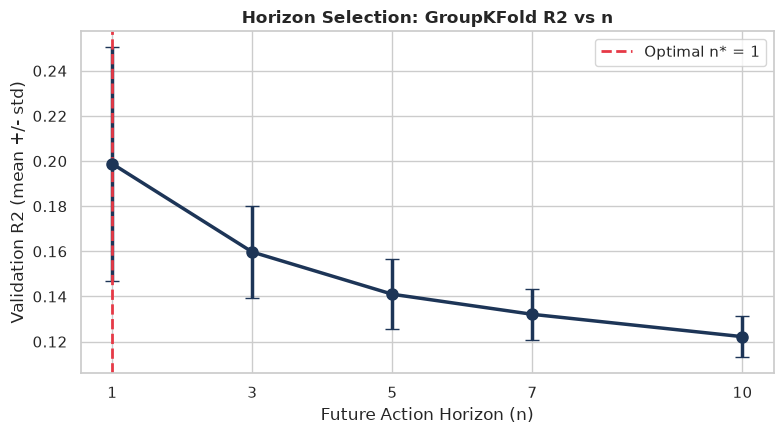

In [9]:
groups = df_360['match_id'].values
gkf    = GroupKFold(n_splits=5)

horizon_results = []
for n in HORIZONS:
    y_n = df_360[f'target_xT_n{n}'].values
    fold_r2, fold_mae, fold_rho = [], [], []
    for tr_idx, val_idx in gkf.split(X_full, y_n, groups):
        cb_h = CatBoostRegressor(
            iterations=300, depth=6, learning_rate=0.08,
            l2_leaf_reg=5, min_data_in_leaf=20,
            cat_features=cat_indices, random_seed=42, verbose=0,
        )
        cb_h.fit(X_full.iloc[tr_idx], y_n[tr_idx])
        pred_val = cb_h.predict(X_full.iloc[val_idx])
        fold_r2.append(r2_score(y_n[val_idx], pred_val))
        fold_mae.append(mean_absolute_error(y_n[val_idx], pred_val))
        rho, _ = spearmanr(y_n[val_idx], pred_val)
        fold_rho.append(rho)
    horizon_results.append({
        'n': n,
        'Val_R2_mean': round(np.mean(fold_r2), 4), 'Val_R2_std': round(np.std(fold_r2), 4),
        'Val_MAE_mean': round(np.mean(fold_mae), 6),
        'Val_Spearman': round(np.mean(fold_rho), 4),
    })
    print(f"  Horizon n={n:2d} | R2: {np.mean(fold_r2):.4f}+/-{np.std(fold_r2):.4f} | MAE: {np.mean(fold_mae):.5f} | Spearman: {np.mean(fold_rho):.4f}")

hor_df = pd.DataFrame(horizon_results)
best_n = int(hor_df.loc[hor_df['Val_R2_mean'].idxmax(), 'n'])
print(f"\nOptimal horizon: n* = {best_n}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(hor_df['n'], hor_df['Val_R2_mean'], yerr=hor_df['Val_R2_std'], marker='o', lw=2.5,
            color='#1d3557', capsize=5, markersize=8)
ax.axvline(best_n, color='#e63946', linestyle='--', lw=2, label=f'Optimal n* = {best_n}')
ax.set_title('Horizon Selection: GroupKFold R2 vs n', fontsize=12, fontweight='bold')
ax.set_xlabel('Future Action Horizon (n)'); ax.set_ylabel('Validation R2 (mean +/- std)')
ax.legend(); ax.set_xticks(HORIZONS)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_final_horizon_selection.png'), dpi=200, bbox_inches='tight')
plt.show()


## Step 10: 4-Way Model Benchmark -- Ridge, RF, CatBoost, MLP

Fold 1 | Ridge R2=0.0324 | RF R2=0.1109 | CatBoost R2=0.1717 | MLP R2=0.1473
Fold 2 | Ridge R2=0.0453 | RF R2=0.1375 | CatBoost R2=0.2510 | MLP R2=0.1834
Fold 3 | Ridge R2=0.0516 | RF R2=0.1131 | CatBoost R2=0.2249 | MLP R2=0.0909
Fold 4 | Ridge R2=0.0475 | RF R2=0.1267 | CatBoost R2=0.2195 | MLP R2=0.1284
Fold 5 | Ridge R2=0.0359 | RF R2=0.0922 | CatBoost R2=0.1060 | MLP R2=0.1170

=== 5-Fold GroupKFold Results (mean +/- std) ===
Ridge           -- R2: 0.0425 +/- 0.0081 | MAE: 0.00348 | Spearman: 0.0684
Random Forest   -- R2: 0.1161 +/- 0.0171 | MAE: 0.00306 | Spearman: 0.1161
CatBoost        -- R2: 0.1946 +/- 0.0572 | MAE: 0.00296 | Spearman: 0.1196
MLP             -- R2: 0.1334 +/- 0.0346 | MAE: 0.00299 | Spearman: 0.0915


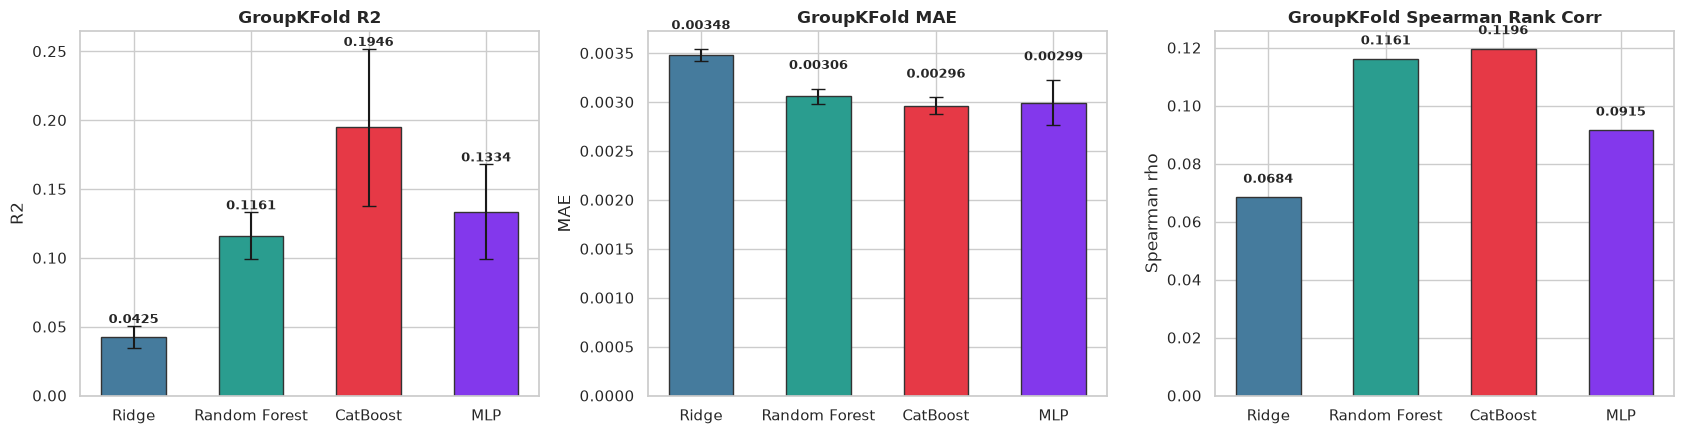


Best model by CV R2: CatBoost


In [10]:
y_final = df_360[f'target_xT_n{best_n}'].values
lr_results, rf_results, cb_results, mlp_results = [], [], [], []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_full, y_final, groups), 1):
    X_tr_cat, X_val_cat = X_full.iloc[tr_idx], X_full.iloc[val_idx]
    X_tr_oh,  X_val_oh  = X_full_onehot.iloc[tr_idx], X_full_onehot.iloc[val_idx]
    y_tr, y_val = y_final[tr_idx], y_final[val_idx]

    scaler   = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_tr_oh)
    X_val_sc = scaler.transform(X_val_oh)

    # 1. Ridge
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_tr_sc, y_tr)
    lr_pred = ridge.predict(X_val_sc)
    rho_lr, _ = spearmanr(y_val, lr_pred)
    lr_results.append({'Fold': fold, 'MAE': mean_absolute_error(y_val, lr_pred),
                       'R2': r2_score(y_val, lr_pred), 'Spearman': rho_lr})

    # 2. Random Forest
    rf = RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_leaf=15,
                                max_features='sqrt', random_state=42, n_jobs=-1)
    rf.fit(X_tr_oh, y_tr)
    rf_pred = rf.predict(X_val_oh)
    rho_rf, _ = spearmanr(y_val, rf_pred)
    rf_results.append({'Fold': fold, 'MAE': mean_absolute_error(y_val, rf_pred),
                       'R2': r2_score(y_val, rf_pred), 'Spearman': rho_rf})

    # 3. CatBoost
    cb = CatBoostRegressor(iterations=500, depth=6, learning_rate=0.05, l2_leaf_reg=5,
                            min_data_in_leaf=20, cat_features=cat_indices, random_seed=42, verbose=0)
    cb.fit(X_tr_cat, y_tr)
    cb_pred = cb.predict(X_val_cat)
    rho_cb, _ = spearmanr(y_val, cb_pred)
    cb_results.append({'Fold': fold, 'MAE': mean_absolute_error(y_val, cb_pred),
                       'R2': r2_score(y_val, cb_pred), 'Spearman': rho_cb})

    # 4. MLP
    mlp = MLPRegressor(hidden_layer_sizes=(64, 32, 16), activation='relu', alpha=1e-3,
                        learning_rate_init=1e-3, early_stopping=True, validation_fraction=0.15,
                        n_iter_no_change=15, max_iter=500, random_state=42)
    mlp.fit(X_tr_sc, y_tr)
    mlp_pred = mlp.predict(X_val_sc)
    rho_mlp, _ = spearmanr(y_val, mlp_pred)
    mlp_results.append({'Fold': fold, 'MAE': mean_absolute_error(y_val, mlp_pred),
                       'R2': r2_score(y_val, mlp_pred), 'Spearman': rho_mlp})

    print(f"Fold {fold} | Ridge R2={lr_results[-1]['R2']:.4f} | RF R2={rf_results[-1]['R2']:.4f} "
          f"| CatBoost R2={cb_results[-1]['R2']:.4f} | MLP R2={mlp_results[-1]['R2']:.4f}")

lr_df  = pd.DataFrame(lr_results)
rf_df  = pd.DataFrame(rf_results)
cb_df  = pd.DataFrame(cb_results)
mlp_df = pd.DataFrame(mlp_results)

print("\n=== 5-Fold GroupKFold Results (mean +/- std) ===")
for name, d in [('Ridge', lr_df), ('Random Forest', rf_df), ('CatBoost', cb_df), ('MLP', mlp_df)]:
    print(f"{name:15s} -- R2: {d['R2'].mean():.4f} +/- {d['R2'].std():.4f} "
          f"| MAE: {d['MAE'].mean():.5f} | Spearman: {d['Spearman'].mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
models  = ['Ridge', 'Random Forest', 'CatBoost', 'MLP']
r2_means  = [lr_df['R2'].mean(), rf_df['R2'].mean(), cb_df['R2'].mean(), mlp_df['R2'].mean()]
r2_stds   = [lr_df['R2'].std(),  rf_df['R2'].std(),  cb_df['R2'].std(),  mlp_df['R2'].std()]
mae_means = [lr_df['MAE'].mean(), rf_df['MAE'].mean(), cb_df['MAE'].mean(), mlp_df['MAE'].mean()]
mae_stds  = [lr_df['MAE'].std(),  rf_df['MAE'].std(),  cb_df['MAE'].std(),  mlp_df['MAE'].std()]
rho_means = [lr_df['Spearman'].mean(), rf_df['Spearman'].mean(), cb_df['Spearman'].mean(), mlp_df['Spearman'].mean()]
colors = ['#457b9d', '#2a9d8f', '#e63946', '#8338ec']

axes[0].bar(models, r2_means, yerr=r2_stds, capsize=5, color=colors, edgecolor='#333', width=0.55)
axes[0].set_title('GroupKFold R2', fontsize=12, fontweight='bold'); axes[0].set_ylabel('R2')
for i, (v, s) in enumerate(zip(r2_means, r2_stds)):
    axes[0].text(i, max(0.001, v + s + 0.002), f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(models, mae_means, yerr=mae_stds, capsize=5, color=colors, edgecolor='#333', width=0.55)
axes[1].set_title('GroupKFold MAE', fontsize=12, fontweight='bold'); axes[1].set_ylabel('MAE')
for i, (v, s) in enumerate(zip(mae_means, mae_stds)):
    axes[1].text(i, v + s + 0.0002, f'{v:.5f}', ha='center', fontsize=9, fontweight='bold')

axes[2].bar(models, rho_means, color=colors, edgecolor='#333', width=0.55)
axes[2].set_title('GroupKFold Spearman Rank Corr', fontsize=12, fontweight='bold'); axes[2].set_ylabel('Spearman rho')
for i, v in enumerate(rho_means):
    axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_final_model_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

best_model_name = pd.Series({'Ridge': r2_means[0], 'Random Forest': r2_means[1],
                              'CatBoost': r2_means[2], 'MLP': r2_means[3]}).idxmax()
print(f"\nBest model by CV R2: {best_model_name}")


## Step 11: Final Model Fit (CatBoost, on all training data)

In [11]:
cb_final = CatBoostRegressor(iterations=500, depth=6, learning_rate=0.05, l2_leaf_reg=5,
                              min_data_in_leaf=20, cat_features=cat_indices, random_seed=42, verbose=0)
cb_final.fit(X_full, y_final)
df_360['aura_score_pred'] = cb_final.predict(X_full)

train_pred = cb_final.predict(X_full)
rho_train, _ = spearmanr(y_final, train_pred)
print("=== Final Model -- In-sample (training data) ===")
print(f"  R2      : {r2_score(y_final, train_pred):.4f}")
print(f"  MAE     : {mean_absolute_error(y_final, train_pred):.5f}")
print(f"  Spearman: {rho_train:.4f}")
print(f"\nCross-validated estimate (GroupKFold -- honest):")
print(f"  R2      : {cb_df['R2'].mean():.4f} +/- {cb_df['R2'].std():.4f}")
print(f"  MAE     : {cb_df['MAE'].mean():.5f}")
print(f"  Spearman: {cb_df['Spearman'].mean():.4f}")


=== Final Model -- In-sample (training data) ===
  R2      : 0.3409
  MAE     : 0.00287
  Spearman: 0.1247

Cross-validated estimate (GroupKFold -- honest):
  R2      : 0.1946 +/- 0.0572
  MAE     : 0.00296
  Spearman: 0.1196


## Step 12: Euro 2024 Held-Out Test (20 matches, first time seen)

In [12]:
print("Extracting Euro 2024 (held-out tournament -- first time seen)...")
matches_euro24 = sb.matches(competition_id=55, season_id=282)
ho_match_ids = matches_euro24.sort_values(by='match_date', ascending=False).head(20)['match_id'].tolist()

ho_rows = []
for i, mid in enumerate(ho_match_ids, 1):
    t_m = time.time()
    rows = process_match(mid)
    ho_rows.extend(rows)
    print(f"  [{i}/{len(ho_match_ids)}] Match {mid}: {len(rows)} events in {time.time()-t_m:.1f}s")

df_euro24 = pd.DataFrame(ho_rows)
df_euro24['type_name']         = df_euro24['type'].apply(extract_name)
df_euro24['play_pattern_name'] = df_euro24['play_pattern'].apply(extract_name)
df_euro24['pass_outcome_name'] = df_euro24['pass_outcome'].apply(extract_name)
df_euro24['position_name']     = df_euro24['position'].apply(extract_name)
df_euro24['player_name']       = df_euro24['player'].apply(extract_name)

df_euro24_360 = df_euro24[df_euro24['has_360'] == True].copy()

# Apply same action valuation
df_euro24_360['action_value_raw'] = df_euro24_360.apply(action_xT_delta, axis=1)
press_bonus_ho = df_euro24_360['under_pressure'].astype(float) * 0.005
df_euro24_360['action_value'] = np.where(
    df_euro24_360['action_value_raw'] >= 0,
    df_euro24_360['action_value_raw'] + press_bonus_ho,
    df_euro24_360['action_value_raw']
)

# Same filtering
df_euro24_360 = df_euro24_360[~df_euro24_360['type_name'].isin(REMOVE_TYPES)].copy()

# Sort and compute chain targets
df_euro24_360 = df_euro24_360.sort_values(['match_id', 'possession', 'minute', 'second']).reset_index(drop=True)

target_ho = np.zeros(len(df_euro24_360))
for k in range(1, best_n + 1):
    shifted_val = df_euro24_360['action_value'].shift(-k).fillna(0).values
    valid_mask = (
        (df_euro24_360['match_id'] == df_euro24_360['match_id'].shift(-k)) &
        (df_euro24_360['possession'] == df_euro24_360['possession'].shift(-k))
    ).values
    target_ho += np.where(valid_mask, shifted_val, 0.0) * (GAMMA ** (k - 1))
df_euro24_360[f'target_xT_n{best_n}'] = target_ho

# Same derived features
oe_ho = df_euro24_360['opponents_eliminated'].fillna(0)
ov_ho = df_euro24_360['opponents_visible'].fillna(10)
tv_ho = df_euro24_360['teammates_visible'].fillna(5)
df_euro24_360['line_break_ratio']       = oe_ho / (ov_ho + 1.0)
df_euro24_360['pressure_relief']        = df_euro24_360['pressing_intensity'].fillna(0) * df_euro24_360['spatial_superiority'].fillna(0)
df_euro24_360['space_creation_index']   = df_euro24_360['short_combo_options'].fillna(0) / (df_euro24_360['opponents_within_5m'].fillna(0) + 1.0)
df_euro24_360['pass_progression_ratio'] = df_euro24_360['forward_passing_options'].fillna(0) / (tv_ho + 1.0)

# Lag features
grp_ho = df_euro24_360.groupby(['match_id', 'possession'])
df_euro24_360['prev_type_name']          = grp_ho['type_name'].shift(1).fillna('NONE')
df_euro24_360['prev_pressing_intensity'] = grp_ho['pressing_intensity'].shift(1).fillna(0)
df_euro24_360['prev_action_value']       = grp_ho['action_value'].shift(1).fillna(0)
df_euro24_360['prev_location_x']        = grp_ho['location_x'].shift(1)
df_euro24_360['prev_location_y']        = grp_ho['location_y'].shift(1)
df_euro24_360['possession_action_num']  = grp_ho.cumcount()

dx_ho = df_euro24_360['location_x'] - df_euro24_360['prev_location_x'].fillna(df_euro24_360['location_x'])
dy_ho = df_euro24_360['location_y'] - df_euro24_360['prev_location_y'].fillna(df_euro24_360['location_y'])
df_euro24_360['dist_from_prev'] = np.sqrt(dx_ho**2 + dy_ho**2)
df_euro24_360['dx_from_prev']   = dx_ho.fillna(0)

# Numeric cleanup (fill with training medians)
for c in NUMERIC_FEATURES:
    df_euro24_360[c] = pd.to_numeric(df_euro24_360[c], errors='coerce').fillna(df_360[c].median())
df_euro24_360['under_pressure'] = df_euro24_360['under_pressure'].astype(int)
for c in CAT_FEATURES:
    df_euro24_360[c] = df_euro24_360[c].fillna('Unknown').astype(str)

X_euro24 = df_euro24_360[ALL_FEATURES].copy()
y_euro24 = df_euro24_360[f'target_xT_n{best_n}'].values

euro24_pred = cb_final.predict(X_euro24)
ho_r2  = r2_score(y_euro24, euro24_pred)
ho_mae = mean_absolute_error(y_euro24, euro24_pred)
ho_rho, _ = spearmanr(y_euro24, euro24_pred)

print(f"\nEuro 2024: {len(df_euro24):,} total events, {len(df_euro24_360):,} actionable with 360")
print("=== Euro 2024 Held-Out Test Results (20 Matches, First Time Seen) ===")
print(f"  R2      : {ho_r2:.4f}")
print(f"  MAE     : {ho_mae:.5f}")
print(f"  Spearman: {ho_rho:.4f}")


Extracting Euro 2024 (held-out tournament -- first time seen)...
  [1/20] Match 3943043: 3304 events in 13.3s
  [2/20] Match 3942819: 3503 events in 12.2s
  [3/20] Match 3942752: 3330 events in 11.5s
  [4/20] Match 3942382: 3417 events in 13.0s
  [5/20] Match 3942227: 4890 events in 16.6s
  [6/20] Match 3942349: 5195 events in 17.4s
  [7/20] Match 3942226: 4463 events in 14.7s
  [8/20] Match 3941021: 2998 events in 9.8s
  [9/20] Match 3941022: 3720 events in 12.3s
  [10/20] Match 3941019: 3943 events in 13.8s
  [11/20] Match 3941020: 4225 events in 15.3s
  [12/20] Match 3941017: 4764 events in 16.4s
  [13/20] Match 3941018: 3948 events in 15.5s
  [14/20] Match 3940878: 3852 events in 13.8s
  [15/20] Match 3940983: 3640 events in 13.5s
  [16/20] Match 3938644: 3659 events in 13.0s
  [17/20] Match 3930183: 2880 events in 11.2s
  [18/20] Match 3930184: 2953 events in 10.6s
  [19/20] Match 3938645: 3526 events in 12.1s
  [20/20] Match 3930180: 3206 events in 12.1s

Euro 2024: 75,416 total 

## Step 13: TreeSHAP Explainability

Computing TreeSHAP explanations for CatBoost...
=== Top Features by |SHAP| ===
           Feature  Mean_SHAP_Abs
      dist_to_goal       0.001024
 prev_action_value       0.000521
         type_name       0.000431
          duration       0.000399
        location_x       0.000297
pressing_intensity       0.000282
     angle_to_goal       0.000282
  closest_opp_dist       0.000263
  line_break_ratio       0.000149
    under_pressure       0.000137
    prev_type_name       0.000114
   pressure_relief       0.000110
      dx_from_prev       0.000094
 opponents_visible       0.000093
 play_pattern_name       0.000082


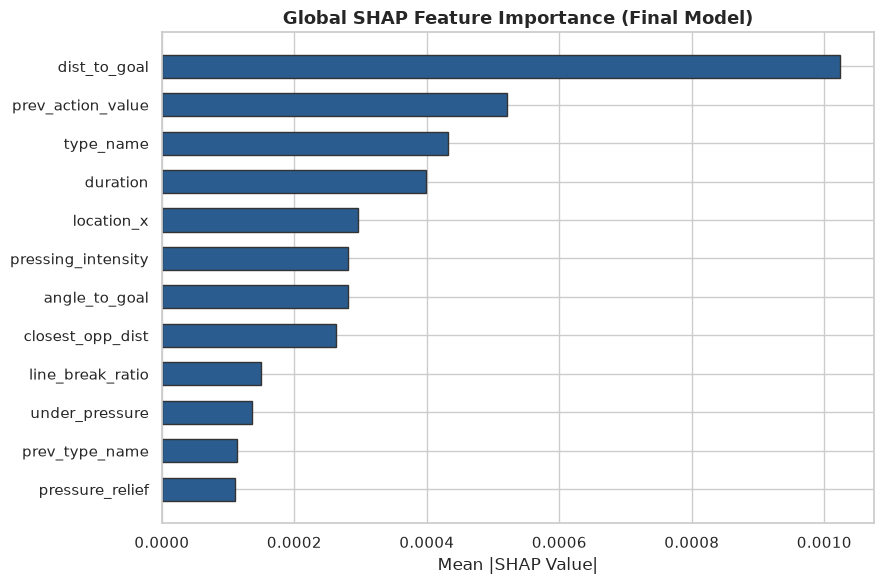

In [13]:
print("Computing TreeSHAP explanations for CatBoost...")
explainer   = shap.TreeExplainer(cb_final)
shap_sample = X_full.sample(min(1000, len(X_full)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

shap_df = pd.DataFrame({
    'Feature': X_full.columns,
    'Mean_SHAP_Abs': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP_Abs', ascending=False)

shap_df.to_csv(os.path.join(DATA_DIR, 'shap_feature_importance_final.csv'), index=False)
print("=== Top Features by |SHAP| ===")
print(shap_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
top12 = shap_df.head(12)
ax.barh(top12['Feature'], top12['Mean_SHAP_Abs'], color='#2b5c8f', edgecolor='#333', height=0.6)
ax.set_title('Global SHAP Feature Importance (Final Model)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|'); ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_final_shap.png'), dpi=200, bbox_inches='tight')
plt.show()


## Step 14: Position & Player Leaderboards

In [14]:
pos_summary = df_360.groupby('position_name').agg(
    total_aura_score = ('aura_score_pred', 'sum'),
    mean_aura_score  = ('aura_score_pred', 'mean'),
    std_aura_score   = ('aura_score_pred', 'std'),
    total_actions    = ('event_id', 'count'),
    mean_action_val  = ('action_value', 'mean'),
).sort_values('mean_aura_score', ascending=False).round(5)
pos_summary.to_csv(os.path.join(DATA_DIR, 'aura_score_by_position_final.csv'))
print("=== Position-Level Mean Aura Score ===")
print(pos_summary.to_string())

# Position-normalized z-score
df_360['pos_z_score'] = df_360.groupby('position_name')['aura_score_pred'].transform(
    lambda s: (s - s.mean()) / s.std() if s.std() > 0 else 0.0
)

player_summary = df_360.groupby('player_name').agg(
    total_aura_score = ('aura_score_pred', 'sum'),
    mean_aura_score  = ('aura_score_pred', 'mean'),
    mean_pos_z_score = ('pos_z_score', 'mean'),
    action_val_mean  = ('action_value', 'mean'),
    line_breaks      = ('opponents_eliminated', 'mean'),
    total_actions    = ('event_id', 'count'),
    matches          = ('match_id', 'nunique'),
    position         = ('position_name', 'first'),
).round(5)
player_summary['aura_per_match'] = (player_summary['total_aura_score'] / player_summary['matches']).round(5)
player_summary = player_summary[(player_summary['total_actions'] >= 50) & (player_summary['matches'] >= 2)]

print("\n=== Top 20 by raw total Aura Score ===")
print(player_summary.sort_values('total_aura_score', ascending=False).head(20).to_string())

print("\n=== Top 20 by position-normalized z-score ===")
print(player_summary.sort_values('mean_pos_z_score', ascending=False).head(20).to_string())

# Focus: Top midfielders
mid_mask = player_summary['position'].str.contains('Midfield', na=False)
print("\n=== Top 20 MIDFIELDERS by position-normalized z-score ===")
print(player_summary[mid_mask].sort_values('mean_pos_z_score', ascending=False).head(20).to_string())

player_summary.to_csv(os.path.join(DATA_DIR, 'player_aura_leaderboard_final.csv'))


=== Position-Level Mean Aura Score ===
                           total_aura_score  mean_aura_score  std_aura_score  total_actions  mean_action_val
position_name                                                                                               
Center Forward                     37.57480          0.00325         0.01215          11567          0.00746
Right Center Forward               14.57437          0.00296         0.01102           4917          0.00648
Left Center Forward                13.07055          0.00256         0.01047           5105          0.00523
Right Attacking Midfield            4.10482          0.00234         0.00545           1752          0.00248
Right Wing                         28.84384          0.00234         0.00872          12337          0.00359
Left Wing                          28.21814          0.00233         0.00883          12101          0.00388
Left Attacking Midfield             4.20868          0.00217         0.01420           19

## Step 15: Defensive-Weight Sensitivity Sweep

In [15]:
def action_value_with_weights(row, w_recovery, w_pressure, w_duel, w_block, w_clearance):
    t = row['type_name']
    if t == 'Shot':
        xg = row.get('shot_statsbomb_xg')
        if pd.notna(xg) and float(xg) > 0:
            return float(xg)
        outcome = extract_name(row.get('shot_outcome'))
        return 0.95 if outcome == 'Goal' else 0.05
    if t in ('Pass', 'Carry'):
        sx, sy = row.get('location_x'), row.get('location_y')
        if t == 'Pass':
            ex, ey = row.get('pass_end_location_x'), row.get('pass_end_location_y')
            outcome = extract_name(row.get('pass_outcome'))
            if outcome in ('Incomplete', 'Out', 'Pass Offside', 'Unknown'):
                return -0.005
        else:
            ex, ey = row.get('carry_end_location_x'), row.get('carry_end_location_y')
        if pd.notna(sx) and pd.notna(sy) and pd.notna(ex) and pd.notna(ey):
            szx, szy = zone_of(sx, sy); ezx, ezy = zone_of(ex, ey)
            return float(xT[ezx, ezy] - xT[szx, szy])
    if t in ('Ball Recovery', 'Interception'):
        sx, sy = row.get('location_x'), row.get('location_y')
        if pd.notna(sx) and pd.notna(sy):
            szx, szy = zone_of(sx, sy); return float(xT[szx, szy] * w_recovery)
    if t == 'Pressure':
        sx, sy = row.get('location_x'), row.get('location_y')
        if pd.notna(sx) and pd.notna(sy):
            szx, szy = zone_of(sx, sy); return float(xT[szx, szy] * w_pressure)
    if t == 'Duel':
        outcome = extract_name(row.get('duel_outcome'))
        if outcome in ('Won', 'Success In Play', 'Success Out'):
            sx, sy = row.get('location_x'), row.get('location_y')
            if pd.notna(sx) and pd.notna(sy):
                szx, szy = zone_of(sx, sy); return float(xT[szx, szy] * w_duel)
        return 0.0
    if t == 'Block':
        sx, sy = row.get('location_x'), row.get('location_y')
        if pd.notna(sx) and pd.notna(sy):
            szx, szy = zone_of(sx, sy); return float(xT[szx, szy] * w_block)
    if t == 'Clearance':
        sx, sy = row.get('location_x'), row.get('location_y')
        if pd.notna(sx) and pd.notna(sy):
            szx, szy = zone_of(sx, sy); return float(xT[szx, szy] * w_clearance)
    return 0.0

WEIGHT_GRID = [
    dict(w_recovery=0.35, w_pressure=0.15, w_duel=0.25, w_block=0.30, w_clearance=0.20),
    dict(w_recovery=0.50, w_pressure=0.25, w_duel=0.35, w_block=0.40, w_clearance=0.30),
    dict(w_recovery=0.65, w_pressure=0.35, w_duel=0.45, w_block=0.50, w_clearance=0.40),
]

sweep_results = []
for gi, weights in enumerate(WEIGHT_GRID):
    df_360['_sweep_action_val'] = df_360.apply(lambda r: action_value_with_weights(r, **weights), axis=1)
    press_bonus_s = df_360['under_pressure'].astype(float) * 0.005
    df_360['_sweep_action_val'] = np.where(df_360['_sweep_action_val'] >= 0,
                                            df_360['_sweep_action_val'] + press_bonus_s,
                                            df_360['_sweep_action_val'])
    sweep_target = (
        df_360.groupby(['match_id', 'possession'])['_sweep_action_val']
        .transform(lambda s: sum(s.shift(-k).fillna(0) * (GAMMA ** (k-1)) for k in range(1, best_n+1)))
    ).values

    fold_r2 = []
    for tr_idx, val_idx in gkf.split(X_full, sweep_target, groups):
        cb_s = CatBoostRegressor(iterations=300, depth=6, learning_rate=0.08, l2_leaf_reg=5,
                                  min_data_in_leaf=20, cat_features=cat_indices, random_seed=42, verbose=0)
        cb_s.fit(X_full.iloc[tr_idx], sweep_target[tr_idx])
        fold_r2.append(r2_score(sweep_target[val_idx], cb_s.predict(X_full.iloc[val_idx])))

    sweep_results.append({
        'grid_index': gi, **weights,
        'CV_R2_mean': np.mean(fold_r2), 'CV_R2_std': np.std(fold_r2),
    })
    print(f"Grid {gi} {weights} -> CV R2={np.mean(fold_r2):.4f}+/-{np.std(fold_r2):.4f}")

sweep_df = pd.DataFrame(sweep_results)
sweep_df.to_csv(os.path.join(DATA_DIR, 'weight_sensitivity_sweep_final.csv'), index=False)
print("\n=== Full Sweep ===")
print(sweep_df.to_string(index=False))

df_360.drop(columns=['_sweep_action_val'], inplace=True, errors='ignore')


Grid 0 {'w_recovery': 0.35, 'w_pressure': 0.15, 'w_duel': 0.25, 'w_block': 0.3, 'w_clearance': 0.2} -> CV R2=0.1913+/-0.0570
Grid 1 {'w_recovery': 0.5, 'w_pressure': 0.25, 'w_duel': 0.35, 'w_block': 0.4, 'w_clearance': 0.3} -> CV R2=0.1988+/-0.0518
Grid 2 {'w_recovery': 0.65, 'w_pressure': 0.35, 'w_duel': 0.45, 'w_block': 0.5, 'w_clearance': 0.4} -> CV R2=0.1983+/-0.0510

=== Full Sweep ===
 grid_index  w_recovery  w_pressure  w_duel  w_block  w_clearance  CV_R2_mean  CV_R2_std
          0        0.35        0.15    0.25      0.3          0.2    0.191319   0.057029
          1        0.50        0.25    0.35      0.4          0.3    0.198841   0.051790
          2        0.65        0.35    0.45      0.5          0.4    0.198267   0.051050


## Step 16: Summary

In [16]:
print("=" * 70)
print("    FINAL BOSS DOOMED -- CATALYTIC AURA SCORE SUMMARY")
print("=" * 70)
print(f"\nDataset               : {df['match_id'].nunique()} matches, {len(df_360):,} actionable events with 360")
print(f"Target                : Empirical xT chain (n*={best_n}, gamma={GAMMA})")
print(f"Features              : {len(NUMERIC_FEATURES)} numeric + {len(CAT_FEATURES)} categorical")
print(f"                        NEW: type_name, prev_type_name, lag features, possession_action_num")
print(f"                        position_name / player_name EXCLUDED from all model inputs")
print(f"Models compared       : Ridge, RF, CatBoost, MLP (GroupKFold k=5 by match_id)")
print(f"Final model           : CatBoost (depth=6, lr=0.05, l2_leaf_reg=5)")

print(f"\n--- Cross-Validated Metrics (GroupKFold, honest) ---")
summary_table = pd.DataFrame([
    {'Model': 'Ridge',         'CV_R2': lr_df['R2'].mean(),  'CV_MAE': lr_df['MAE'].mean(),  'CV_Spearman': lr_df['Spearman'].mean()},
    {'Model': 'Random Forest', 'CV_R2': rf_df['R2'].mean(),  'CV_MAE': rf_df['MAE'].mean(),  'CV_Spearman': rf_df['Spearman'].mean()},
    {'Model': 'CatBoost',      'CV_R2': cb_df['R2'].mean(),  'CV_MAE': cb_df['MAE'].mean(),  'CV_Spearman': cb_df['Spearman'].mean()},
    {'Model': 'MLP',           'CV_R2': mlp_df['R2'].mean(), 'CV_MAE': mlp_df['MAE'].mean(), 'CV_Spearman': mlp_df['Spearman'].mean()},
]).round(5)
print(summary_table.to_string(index=False))

print(f"\n--- Held-Out Euro 2024 (20 matches, never seen) ---")
print(f"  R2      : {ho_r2:.4f}")
print(f"  MAE     : {ho_mae:.5f}")
print(f"  Spearman: {ho_rho:.4f}")

print(f"\n--- Leakage Status ---")
print(f"  Numeric max|corr|       : {max_corr:.3f}")
print(f"  position/player excluded: YES")
print(f"  Lag features direction  : backward only (shift +1 = previous event)")

print(f"\n--- Improvements vs Previous Notebook ---")
print(f"  Training matches : 15 -> {df['match_id'].nunique()}")
print(f"  Event filtering  : Ball Receipt* and passive events removed")
print(f"  New features     : type_name, prev_type_name, lag context, possession_action_num")
print(f"  New metric       : Spearman rank correlation for ranking validity")


    FINAL BOSS DOOMED -- CATALYTIC AURA SCORE SUMMARY

Dataset               : 115 matches, 255,772 actionable events with 360
Target                : Empirical xT chain (n*=1, gamma=0.88)
Features              : 27 numeric + 3 categorical
                        NEW: type_name, prev_type_name, lag features, possession_action_num
                        position_name / player_name EXCLUDED from all model inputs
Models compared       : Ridge, RF, CatBoost, MLP (GroupKFold k=5 by match_id)
Final model           : CatBoost (depth=6, lr=0.05, l2_leaf_reg=5)

--- Cross-Validated Metrics (GroupKFold, honest) ---
        Model   CV_R2  CV_MAE  CV_Spearman
        Ridge 0.04253 0.00348      0.06840
Random Forest 0.11606 0.00306      0.11612
     CatBoost 0.19461 0.00296      0.11964
          MLP 0.13339 0.00299      0.09155

--- Held-Out Euro 2024 (20 matches, never seen) ---
  R2      : 0.2171
  MAE     : 0.00295
  Spearman: 0.1229

--- Leakage Status ---
  Numeric max|corr|       : 0.125
  